In [5]:
import pandas as pd
import numpy as np
uploaded_data=pd.read_csv("D:\\csv files\\daily_energy_consumption.csv")

In [6]:
uploaded_data

,Date,Consumption (kWh),Temperature (°C),Humidity (%)
0,01-01-2021,3547,18.90,39.34
1,02-01-2021,3947,8.05,50.24
2,03-01-2021,4959,26.60,88.63
3,04-01-2021,3813,8.98,24.73
4,05-01-2021,3583,17.08,56.31
...,...,...,...,...
725,27-12-2022,3665,11.96,28.39
726,28-12-2022,2386,19.64,71.44
727,29-12-2022,4893,31.28,57.20
728,30-12-2022,3429,8.55,40.16


In [9]:
#Converts Date column to datetime
uploaded_data['Date']=pd.to_datetime(uploaded_data['Date'],format='%d-%m-%Y')
uploaded_data.set_index('Date', inplace=True)
uploaded_data.head()

,Consumption (kWh),Temperature (°C),Humidity (%)
Date,,,
2021-01-01,3547,18.90,39.34
2021-01-02,3947,8.05,50.24
2021-01-03,4959,26.60,88.63
2021-01-04,3813,8.98,24.73
2021-01-05,3583,17.08,56.31


In [10]:
uploaded_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 730 entries, 2021-01-01 to 2022-12-31
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Consumption (kWh)  730 non-null    int64  
 1   Temperature (°C)   730 non-null    float64
 2   Humidity (%)       730 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 22.8 KB


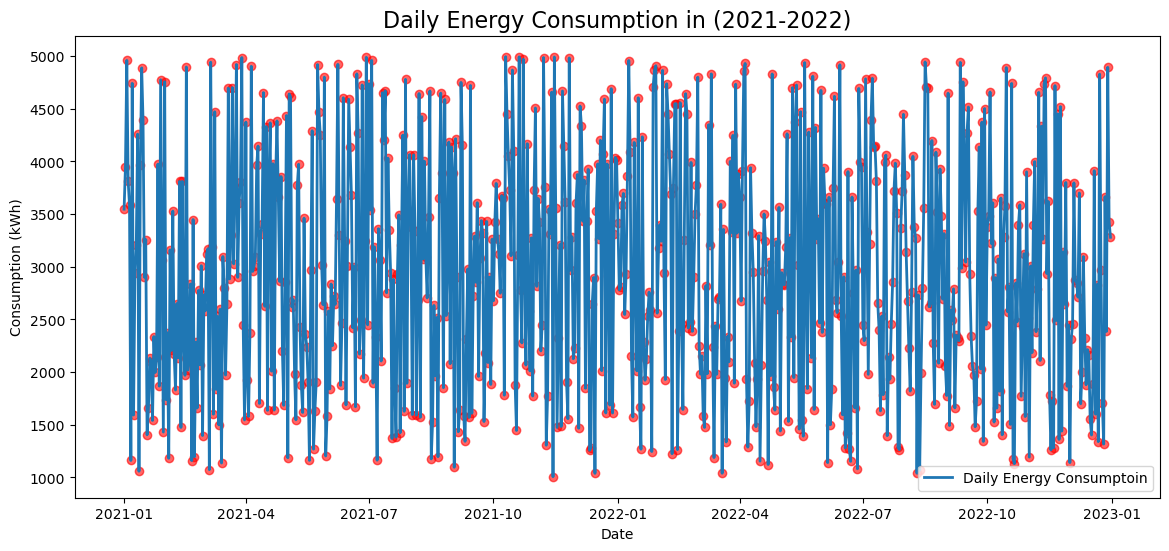

In [21]:
#Visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.scatter(uploaded_data.index,
            uploaded_data['Consumption (kWh)'],
            color='red',
            alpha=0.6)
plt.plot(uploaded_data['Consumption (kWh)'], label='Daily Energy Consumptoin', linewidth=2)
plt.title('Daily Energy Consumption in (2021-2022)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Consumption (kWh)')
plt.legend()
plt.show()

In [23]:
uploaded_data.value_counts()

Consumption (kWh)  Temperature (°C)  Humidity (%)
1007               20.18             83.55           1
3470               28.69             34.30           1
3485               31.57             62.58           1
3492               34.64             63.14           1
3501               20.59             79.32           1
                                                    ..
2337               5.05              25.39           1
                   28.59             60.08           1
2347               28.14             55.09           1
2348               16.39             73.86           1
4994               28.89             20.37           1
Name: count, Length: 730, dtype: int64

In [39]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

consumption_data = uploaded_data[['Consumption (kWh)']]

# Normalize data
scaler = MinMaxScaler(feature_range=(0,1))
consumption_scaled = scaler.fit_transform(consumption_data)

X = []
y = []

n_steps = 30  # last 30 days used to predict next day

for i in range(n_steps, len(consumption_scaled)):
    X.append(consumption_scaled[i-n_steps:i, 0])  # past 30 values
    y.append(consumption_scaled[i, 0])            # next value

# Convert to numpy arrays AFTER loop
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)
 


(700, 30)
(700,)


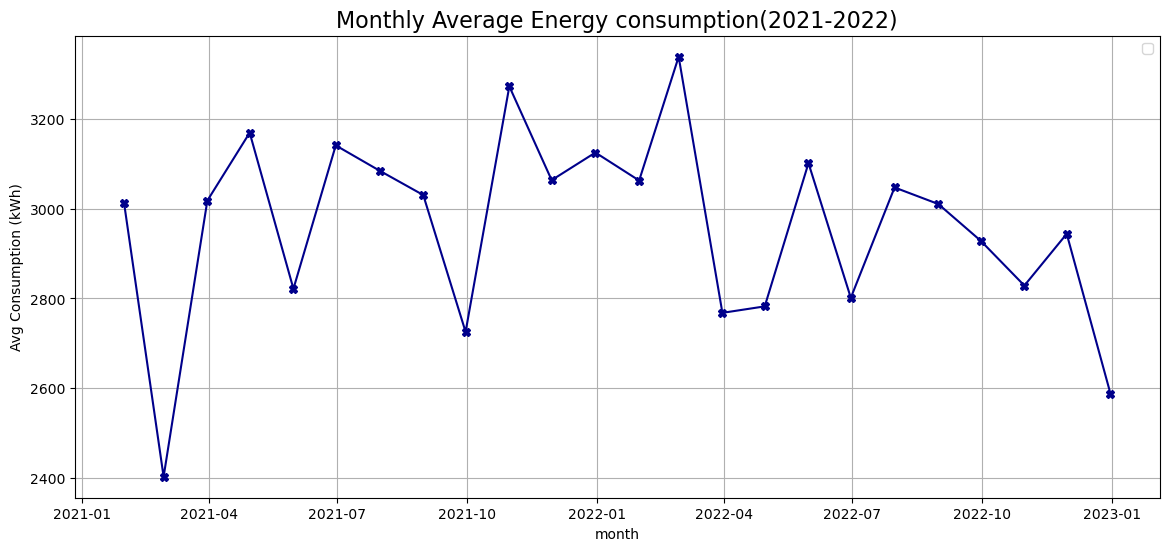

In [60]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
monthly_avg=uploaded_data['Consumption (kWh)'].resample('ME').mean()
plt.figure(figsize=(14,6))
plt.plot(monthly_avg, 
         marker='X',
         linestyle='-',
         color='darkblue')
plt.title('Monthly Average Energy consumption(2021-2022)', fontsize=16)
plt.xlabel('month')
plt.ylabel('Avg Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()


In [76]:
import warnings
warnings.filterwarnings("ignore")
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
model=Sequential()
model.add(SimpleRNN(50, activation='tanh', input_shape=(X.shape[1],1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
history=model.fit(X,y, epochs=30,
                  batch_size=32,
                  validation_split=0.2,
                  verbose=1)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.1181 - val_loss: 0.0813
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0808 - val_loss: 0.0814
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0790 - val_loss: 0.0761
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0768 - val_loss: 0.0860
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0754 - val_loss: 0.0779
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0756 - val_loss: 0.0811
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0757 - val_loss: 0.0841
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0764 - val_loss: 0.0769
Epoch 9/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0754 - val_loss: 0.0822
Epoch 10/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0765 - val_loss: 0.0880
Epoch 11/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0752 - val_loss: 0.0762
Epoch 12/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0727 - val_

TypeError: 'History' object is not subscriptable

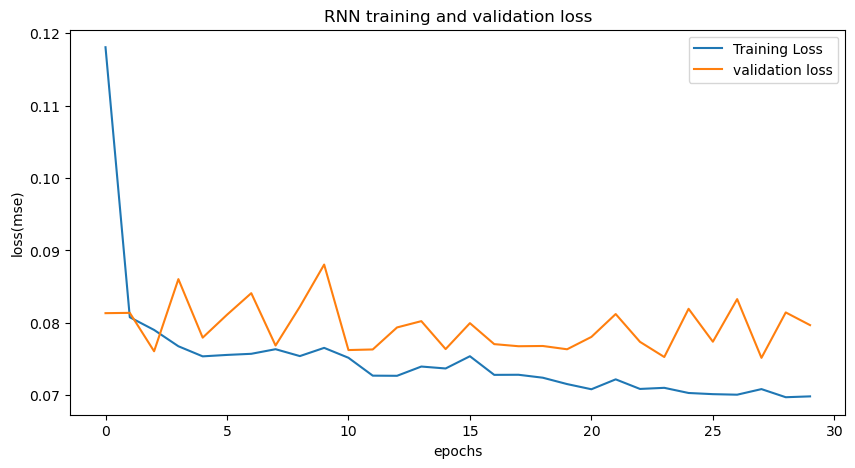

In [79]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.title('RNN training and validation loss')
plt.xlabel('epochs')
plt.ylabel('loss(mse)')
plt.legend()
plt.show()

In [83]:
#predict next 30 days consumption
last_30_days=consumption_scaled[-30:]
last_30_days=last_30_days.reshape(1,n_steps,1)
predicted_scaled=model.predict(last_30_days)
predicted_kwh=scaler.inverse_transform(predicted_scaled)
print(f"predicted next day comsumption:{predicted_kwh[0][0]:.2f},kwh")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
predicted next day comsumption:3092.52,kwh
